# Before your start:
- Read the README.md file
- Comment as much as you can and use the resources in the README.md file
- Happy learning!

In [8]:
# Import your libraries:
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn import datasets

# Challenge 1 - Explore the Scikit-Learn Datasets

Before starting to work on our own datasets, let's first explore the datasets that are included in this Python library. These datasets have been cleaned and formatted for use in ML algorithms.

First, we will load the diabetes dataset. Do this in the cell below by importing the datasets and then loading the dataset  to the `diabetes` variable using the `load_diabetes()` function.

In [ ]:
# Your code here:
# diabetes = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# Load the diabetes dataset
diabetes = datasets.load_diabetes()

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


Let's explore this variable by looking at the different attributes. Do this by looking at the `keys()` of this variable.

In [10]:
# Your code here:
print(diabetes.keys())

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])


The next step is to read the description of the dataset. Print the description in the cell below using the `DESCR` attribute of the `diabetes` variable

In [11]:
# Your code here:
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

What are the variables in this dataset according to the description? List them in the markdown cell below

   - age     age in years
      - sex
      - bmi     body mass index
      - bp      average blood pressure
      - s1      tc, total serum cholesterol
      - s2      ldl, low-density lipoproteins
      - s3      hdl, high-density lipoproteins
      - s4      tch, total cholesterol / HDL
      - s5      ltg, possibly log of serum triglycerides level
      - s6      glu, blood sugar level

#### Enter your answer here:

age, sex, body mass index, average blood pressure, s1, s2, s3, s4, s5, s6




Now explore the data. Scikit-learn typically takes in 2D numpy arrays as input (though pandas dataframes are also accepted). In the cell below find the shape of the numpy array contained in the data portion of the diabetes variable.

In [12]:
# Check the dimensions of the feature array
data_shape = diabetes.data.shape

print(f"The shape of the diabetes data is: {data_shape}")

The shape of the diabetes data is: (442, 10)


# Challenge 2 - Perform Supervised Learning on the Dataset

#### The data has already been split to predictor and response variables. The response variable is in the `target` portion of the variable. 

Given this information, let's apply what we have previously learned about linear regression and apply the algorithm to the diabetes dataset. In the cell below, import the linear regression class from sklearn. 

In [13]:
# Your code here:
from sklearn.linear_model import LinearRegression

Initialize the model in the variable `diabetes_model`

In [ ]:
# Your code here:
X = diabetes.data
y = diabetes.target
diabetes_model = LinearRegression()

In the cell below, fit the model and print the intercept and coefficients of the model. 

In [ ]:
# Your code here:
diabetes_model.fit(X, y)

# Make predictions using the same dataset
predictions = diabetes_model.predict(X)

# Print the Intercept
# (In a real project, you'd usually split data into train/test sets first)
print(f"Intercept: {diabetes_model.intercept_:.4f}")

# Print the Coefficients
print("Coefficients:")
for feature, coef in zip(diabetes.feature_names, diabetes_model.coef_):
    print(f"  {feature}: {coef:.4f}")

Intercept: 152.1335
Coefficients:
  age: -10.0099
  sex: -239.8156
  bmi: 519.8459
  bp: 324.3846
  s1: -792.1756
  s2: 476.7390
  s3: 101.0433
  s4: 177.0632
  s5: 751.2737
  s6: 67.6267


# Bonus Challenge 1 - Conduct a Hypothesis Test on the Model

Once we have generated a linear model, we can test each coefficient using a t-test to see whether the confidence interval for the variable contains zero. We can also perform an overall F test to check whether at least one coefficient is significantly different from zero. 

Refer to the resource in this [link](https://onlinecourses.science.psu.edu/stat501/node/297/) for more details and perform the t-tests for the model above. Additionally, interpret the results and list coefficients are significantly different from zero.


Hint: use the statsmodels package.

Result should look like this:

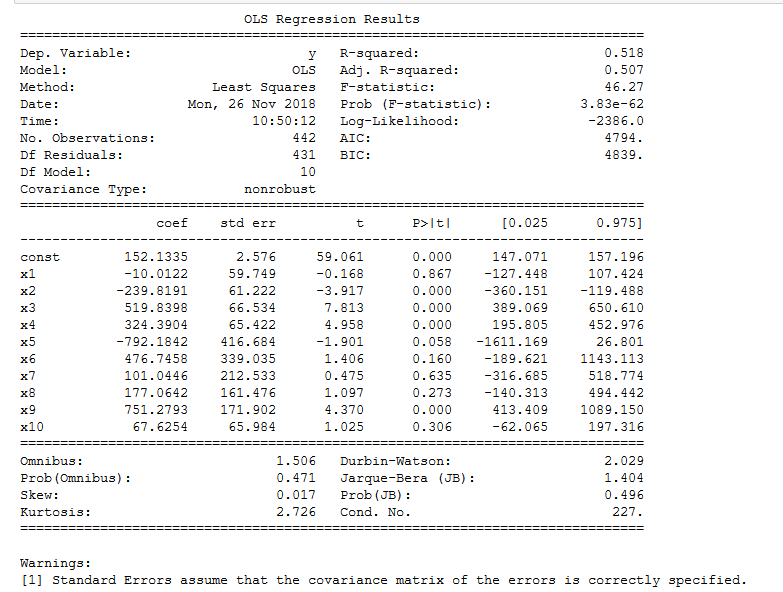


Mean squared error: 2859.6963
The RMSE: 53.4761
R-squared score: 0.52


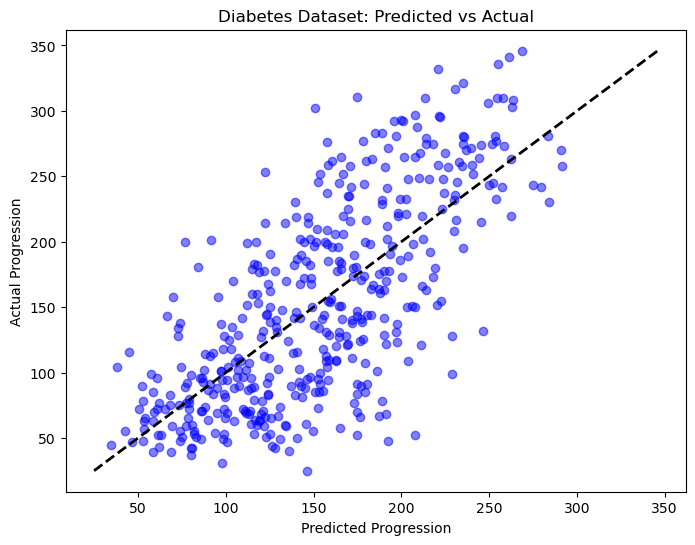

In [ ]:
# Your code here:
import numpy as np
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Calculate and print performance metrics
mean_sqr_error = mean_squared_error(y, predictions)
square_root = np.sqrt(mean_sqr_error)
print(f"\nMean squared error: {mean_sqr_error:.4f}")
print(f"The RMSE: {square_root:.4f}")
print(f"R-squared score: {r2_score(y, predictions):.2f}")

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(predictions, y, color="blue", alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2)  # Diagonal line
plt.xlabel("Predicted Progression")
plt.ylabel("Actual Progression")
plt.title("Diabetes Dataset: Predicted vs Actual")
plt.show()

# This means your predictions are, on average, about 53 points off from the actual disease progression score.
# For this dataset, an R^2 of 0.51 is standard, meaning the model captures about half of the variation in the data.

# Challenge 3 - Peform Supervised Learning on a Pandas Dataframe

Now that we have looked at data that has been formatted for scikit-learn, let's look at data that we will need to format ourselves.

In the next cell, load the `auto-mpg.csv` file included in this folder and assign it to a variable called `auto`.

In [37]:
# Your code here:
auto = pd.read_csv("auto-mpg.csv")

Look at the first 5 rows using the `head()` function:

In [38]:
# Your code here:
auto.head()

,mpg,cylinders,displacement,horse_power,weight,acceleration,model_year,car_name
0,18.0,8,307.0,130.0,3504,12.0,70,"\t""chevrolet chevelle malibu"""
1,15.0,8,350.0,165.0,3693,11.5,70,"\t""buick skylark 320"""
2,18.0,8,318.0,150.0,3436,11.0,70,"\t""plymouth satellite"""
3,16.0,8,304.0,150.0,3433,12.0,70,"\t""amc rebel sst"""
4,17.0,8,302.0,140.0,3449,10.5,70,"\t""ford torino"""


Evaluate the data to ensure that all numeric columns are correctly detected as such by pandas. If a column is misclassified as object, coerce it to numeric.

In [39]:
# Your code here:
auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horse_power     float64
weight            int64
acceleration    float64
model_year        int64
car_name         object
dtype: object

What is the newest model year and the oldest model year?

In [ ]:
# Your code here:
newest_year = auto["model_year"].max()
oldest_year = auto["model_year"].min()
print(f"The newest model year is: {newest_year}")
print(f"The oldest model year is: {oldest_year}")

The newest model year is: 82
The oldest model year is: 70


Check the dataset for missing values and remove all rows containing at least one missing value.

In [42]:
# Your code here:
print(auto.isnull().sum())

mpg             0
cylinders       0
displacement    0
horse_power     6
weight          0
acceleration    0
model_year      0
car_name        0
dtype: int64


In [ ]:
auto.dropna(axis=0, how="any", inplace=True)
print(auto.isnull().sum())

Find the frequency table for the `cylinders` column using the `value_counts()` function. How many possible values of cylinders are there?

In [45]:
# Your code here:
auto["cylinders"].value_counts()

cylinders
4    199
8    103
6     83
3      4
5      3
Name: count, dtype: int64

We would like to generate a linear regression model that will predict mpg. To do this, first drop the `car_name` column since it does not contain any quantitative data. Next separate the dataframe to predictor and response variables. Separate those into test and training data with 80% of the data in the training set and the remainder in the test set. 

Assign the predictor and response training data to `X_train` and `y_train` respectively. Similarly, assign the predictor and response test data to `X_test` and `y_test`.

In [ ]:
# Your code here:
auto_drop_car_name = auto.drop("car_name", axis=1)
auto_drop_car_name.keys()

from sklearn.model_selection import train_test_split

# Separate into predictor (X) and response (y) variables
# mpg is our target (y), everything else is a predictor (X)
X = auto_drop_car_name.drop("mpg", axis=1)
y = auto_drop_car_name["mpg"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1992)

# Check train and test sizes
print(X.shape, X_train.shape, X_test.shape)
print(y.shape, y_train.shape, y_test.shape)
# Verify the split
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

(392, 6) (313, 6) (79, 6)
(392,) (313,) (79,)
Training set size: 313 samples
Test set size: 79 samples


Now we will the dataset that we processed and peform linear regression on this data to predict the mpg for each vehicle. Initialize the model in the cell below.

In [52]:
# Your code here:
mpg_model = LinearRegression()

Next, fit the model in the cell below.

In [54]:
# Your code here:
mpg_model.fit(X_train, y_train)
# Print coefs
print(mpg_model.intercept_, mpg_model.coef_)

-13.495450913392833 [-0.66406891  0.01872743 -0.00838882 -0.00702279  0.17107667  0.73697632]


# Challenge 4 - Evaluate the Model

the r squared score of a model tells us how much variation is explained by the model. In a typical dataset, most observations differ from the mean. When we create a model, we are trying to generate an equation that will tell us by how much each observation will differ from the mean. Obviously, the vast majority of models are not perfect. They can only predict some of the variation from the mean but not all of it. We attribute the rest of the difference between the actual value and the mean to random error. We would like random error to explain the as little as possible of the variation. This is why the r squared score is an important metric.

In the next cell, compute the r squared score of the model. Do this by first computing the predicted values and assign them to `y_pred`.

In [ ]:
# Your code here:
# 1. Generate predicted values using the test features
y_pred = mpg_model.predict(X_test)

# 2. Compute the R-squared score
# We compare the actual values (y_test) with our predictions (y_pred)
r2 = r2_score(y_test, y_pred)

print(f"The R-squared score for the model is: {r2:.4f}")

# R^2 is 0.80: It means your model explains 80% of why some cars get better gas mileage than others.
# The remaining 20% is "noise" or factors not in your data (like driving habits or tire pressure).

The R-squared score for the model is: 0.8033


#### Our next step is to evaluate the model using the test data. We would like to ensure that our model is not overfitting the data. This means that our model will not be able to generalize well outside of the training data.

In the cell below, use the model to generate the predicted values for the training data and assign them to `y_test_pred`. Compute the r squared score for the test data by comparing the oberserved `y_train` data and the predicted `y_test_pred`.

In [ ]:
# Your code here:
# 1. Generate predicted values for the training data
y_train_pred = mpg_model.predict(X_train)

# 2. Compute the R-squared score for the training data
r2_train = r2_score(y_train, y_train_pred)

print(f"Training R-squared Score: {r2_train:.4f}")
print(f"Test R-squared Score: {r2:.4f}")  # This was calculated in  previous step

# The training R^2 is: 0.8063 and test R^2 is 0.8033 are ver very close.
# It has learned the underlying patterns of fuel efficiency and generalizes well to new cars.

Training R-squared Score: 0.8063
Test R-squared Score: 0.8033


# Challenge 5 - Improve the Model Fit

While the most common way to improve the fit of a model is by using regularization, there are other simpler ways to improve model fit. The first is to create a simpler model. The second is to increase the train sample size.

Let us start with the easier option and increase our train sample size to 90% of the data. Create a new test train split and name the new predictors and response variables `X_train09`, `X_test09`, `y_train09`, `y_test09`.

In [ ]:
# Your code here:
from sklearn.model_selection import train_test_split

# Create a new split with 90% training data and 10% test data
# We use the same X and y from your previous step (where car_name was dropped)
X_train09, X_test09, y_train09, y_test09 = train_test_split(X, y, test_size=0.10, random_state=1992)

# Verify the new dimensions
print(f"New Training set size: {X_train09.shape[0]} samples")
print(f"New Test set size: {X_test09.shape[0]} samples")

New Training set size: 352 samples
New Test set size: 40 samples


Initialize a new model. Name this model `auto_model09`. Fit the model to the new sample data.

In [62]:
# Your code here:
# 1. Initialize the new model
auto_model09 = LinearRegression()

# 2. Fit the model to the 90% training data
auto_model09.fit(X_train09, y_train09)

print(auto_model09.intercept_, auto_model09.coef_)

-17.44281326400585 [-0.48884787  0.01239198 -0.00171428 -0.00689755  0.17203687  0.77911572]


Compute the predicted values and r squared score for our new model and new sample data.

In [64]:
# Your code here:
# 1. Compute the predicted values for the new test set
y_pred09 = auto_model09.predict(X_test09)

# 2. Compute the R-squared score
r2_09 = r2_score(y_test09, y_pred09)

print(f"R-squared score with 90% training data: {r2_09:.4f}")

R-squared score with 90% training data: 0.7266


Compute the r squared score for the smaller test set. Is there an improvement in the test r squared?

In [ ]:
# Your code here:
# 1. Calculate the R-squared for the 90/10 split
r2_09 = r2_score(y_test09, y_pred09)

# 2. Compare it to the previous R-squared (from the 80/20 split)
# Note: 'r2' was the variable used in the previous challenge
improvement = r2_09 - r2

print(f"New R-squared (90% train): {r2_09:.4f}")
print(f"Original R-squared (80% train): {r2:.4f}")
print(f"Improvement: {improvement:.4f}")

# If the improvement is negative ($< 0$): The score actually went down.
# This is common when the test set becomes very small (only 10% of the data).
# A smaller test set is more "sensitive"—if the few cars in that 10% happen to be unusual or outliers,
# the R^2 score will drop significantly even if the model is actually better.

New R-squared (90% train): 0.7266
Original R-squared (80% train): 0.8033
Improvement: -0.0768


# Bonus Challenge 2 - Backward Elimination 

The main way to produce a simpler linear regression model is to reduce the number of variables used in the model. In scikit-learn, we can do this by using recursive feature elimination. You can read more about RFE [here](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html).

In the next cell, we will import RFE

In [58]:
from sklearn.feature_selection import RFE

Follow the documentation and initialize an RFE model using the `auto_model` linear regression model. Set `n_features_to_select=3`

In [ ]:
# Your code here:

R-squared score with 90% training data: 0.7266


Fit the model and print the ranking

In [ ]:
# Your code here:

Feature importance is ranked from most important (1) to least important (4). Generate a model with the three most important features. The features correspond to variable names. For example, feature 1 is `cylinders` and feature 2 is `displacement`.

Perform a test-train split on this reduced column data and call the split data `X_train_reduced`, `X_test_reduced`, `y_test_reduced`, `y_train_reduced`. Use an 80% split.

In [ ]:
# Your code here:

Generate a new model called `auto_model_reduced` and fit this model. Then proceed to compute the r squared score for the model. Did this cause an improvement in the r squared score?

In [ ]:
# Your code here: